# 🏦 Machine Learning — Loan Default Prediction
### Exercices 1 à 5 : Problème, Features, Modèles, Évaluation

---

## 🌟 Exercice 1 — Définition du problème et collecte de données

### Problème
Prédire si un demandeur de prêt va **faire défaut de remboursement** (variable cible : `Loan_Status` — Y/N).  
L'objectif est de minimiser le risque de perte pour l'institution financière, tout en évitant de refuser des emprunteurs solvables.

### Types de données nécessaires
| Catégorie | Variables |
|---|---|
| Données personnelles | Âge, sexe, état civil, nombre de personnes à charge |
| Données financières | Revenu du demandeur, revenu du co-demandeur, ratio dette/revenu |
| Informations de prêt | Montant, durée, type de prêt |
| Historique de crédit | Score de crédit, incidents de paiement passés |
| Contexte socio-éco | Niveau d'éducation, statut d'emploi, zone géographique |

### Sources de données
- **Registres internes** de la banque (historique de prêts accordés)
- **Bureaux de crédit** (Experian, Equifax, TransUnion) — score FICO
- **Dossiers de demande** de prêt remplis par les clients
- **Registres d'emploi / fiches de paie** pour vérification des revenus
- **Données fiscales gouvernementales** (avec consentement du client)

---
## 🌟 Exercice 2 — Sélection de features et choix du modèle

### Chargement et exploration du dataset

In [1]:
# Installation des librairies nécessaires
!pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    accuracy_score, precision_score, recall_score
)
from xgboost import XGBClassifier

plt.style.use('seaborn-v0_8-whitegrid')
print('✅ Librairies importées avec succès')

✅ Librairies importées avec succès


In [4]:
# Chargement du dataset Loan Prediction depuis Kaggle (lien direct)
url = 'https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%204/Day%201/Loan%20Predication.zip'
df = pd.read_csv(url)

print(f'Dimensions du dataset : {df.shape}')
print(f'\nPremières lignes :')
df.head()

Dimensions du dataset : (614, 13)

Premières lignes :


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
# Informations générales
print('=== Informations du dataset ===')
df.info()

print('\n=== Valeurs manquantes ===')
print(df.isnull().sum())

print('\n=== Distribution de la variable cible ===')
print(df['Loan_Status'].value_counts())

=== Informations du dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB

=== Valeurs manquantes ===
Loan_ID               0
Gender               13
Marr

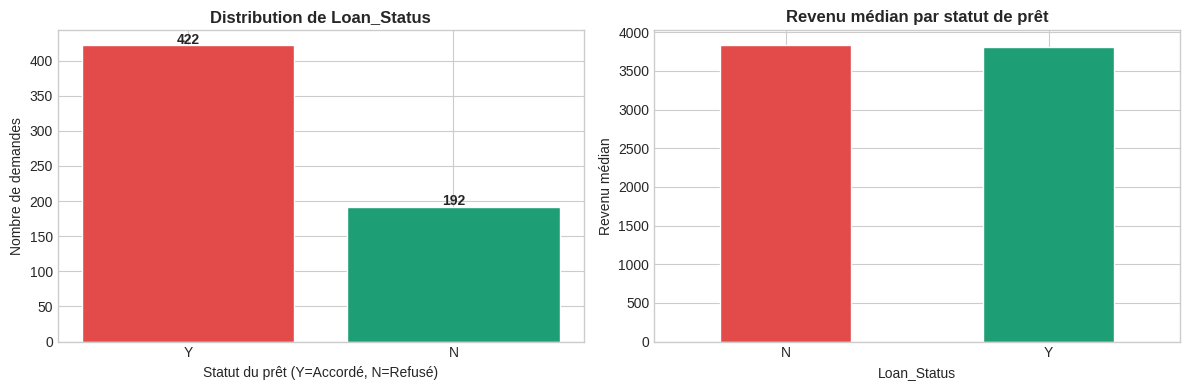

In [6]:
# Visualisation de la distribution de la variable cible
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution Loan_Status
counts = df['Loan_Status'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#E24B4A', '#1D9E75'], edgecolor='white')
axes[0].set_title('Distribution de Loan_Status', fontweight='bold')
axes[0].set_xlabel('Statut du prêt (Y=Accordé, N=Refusé)')
axes[0].set_ylabel('Nombre de demandes')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Revenu vs Loan_Status
df.groupby('Loan_Status')['ApplicantIncome'].median().plot(kind='bar', ax=axes[1],
    color=['#E24B4A', '#1D9E75'], edgecolor='white')
axes[1].set_title('Revenu médian par statut de prêt', fontweight='bold')
axes[1].set_xlabel('Loan_Status')
axes[1].set_ylabel('Revenu médian')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

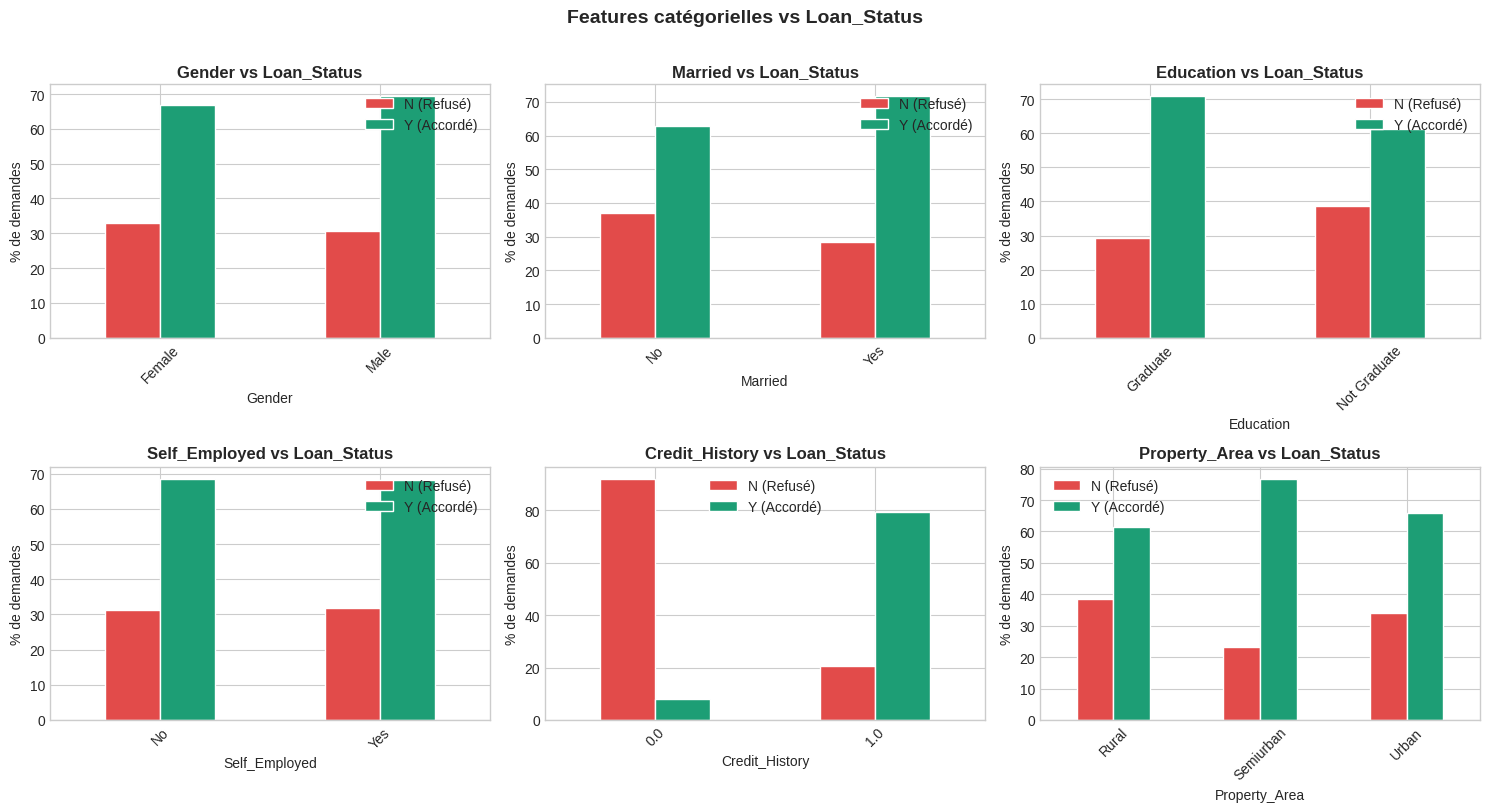

In [7]:
# Analyse des features catégorielles vs Loan_Status
cat_features = ['Gender', 'Married', 'Education', 'Self_Employed', 'Credit_History', 'Property_Area']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(cat_features):
    ct = pd.crosstab(df[feature], df['Loan_Status'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['#E24B4A', '#1D9E75'], edgecolor='white')
    axes[i].set_title(f'{feature} vs Loan_Status', fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('% de demandes')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(['N (Refusé)', 'Y (Accordé)'])

plt.suptitle('Features catégorielles vs Loan_Status', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Justification des features sélectionnées

| Feature | Justification |
|---|---|
| `Credit_History` | Feature la plus corrélée au défaut : historique positif = discipline financière |
| `ApplicantIncome` | Détermine la capacité de remboursement mensuelle |
| `CoapplicantIncome` | Revenu supplémentaire qui améliore la solvabilité |
| `LoanAmount` | Montant à rembourser — ratio mensualité/revenu |
| `Loan_Amount_Term` | Durée du prêt — impacte la mensualité |
| `Property_Area` | Zone urbaine/rurale corrélée à la stabilité économique |
| `Education` | Proxy de stabilité d'emploi et de revenus futurs |
| `Married` | Revenus combinés = meilleure capacité de remboursement |
| `Dependents` | Plus de personnes à charge = moins de capacité disponible |
| `Self_Employed` | Revenus irréguliers = risque potentiellement plus élevé |

---
## 🌟 Exercice 3 — Entraînement, évaluation et optimisation du modèle

In [8]:
# === PRÉTRAITEMENT ===

df_model = df.copy()

# Suppression de la colonne ID
df_model.drop('Loan_ID', axis=1, inplace=True)

# Remplissage des valeurs manquantes
for col in df_model.select_dtypes(include='object').columns:
    df_model[col].fillna(df_model[col].mode()[0], inplace=True)

for col in df_model.select_dtypes(include='number').columns:
    df_model[col].fillna(df_model[col].median(), inplace=True)

# Encodage des variables catégorielles
le = LabelEncoder()
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = le.fit_transform(df_model[col])

# Feature engineering : ratio revenu total / montant du prêt
df_model['Total_Income'] = df_model['ApplicantIncome'] + df_model['CoapplicantIncome']
df_model['EMI'] = df_model['LoanAmount'] / df_model['Loan_Amount_Term']
df_model['Income_to_Loan_Ratio'] = df_model['Total_Income'] / (df_model['LoanAmount'] + 1)

# Séparation features / cible
X = df_model.drop('Loan_Status', axis=1)
y = df_model['Loan_Status']

# Split train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Taille train : {X_train.shape}, Taille test : {X_test.shape}')
print(f'Distribution cible train : {y_train.value_counts().to_dict()}')

Taille train : (491, 14), Taille test : (123, 14)
Distribution cible train : {1: 337, 0: 154}


In [9]:
# === ENTRAÎNEMENT DES MODÈLES ===

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0)
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1')

    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'cv_f1_mean': cv_scores.mean(),
        'cv_f1_std': cv_scores.std(),
        'y_pred': y_pred,
        'y_prob': y_prob,
        'model': model
    }
    print(f'✅ {name} entraîné')

# Tableau comparatif
print('\n=== COMPARAISON DES MODÈLES ===')
comparison = pd.DataFrame({
    name: {
        'Accuracy': f"{r['accuracy']:.3f}",
        'Precision': f"{r['precision']:.3f}",
        'Recall': f"{r['recall']:.3f}",
        'F1-Score': f"{r['f1']:.3f}",
        'ROC-AUC': f"{r['roc_auc']:.3f}",
        'CV F1 (mean±std)': f"{r['cv_f1_mean']:.3f}±{r['cv_f1_std']:.3f}"
    }
    for name, r in results.items()
}).T

print(comparison)

✅ Logistic Regression entraîné
✅ Random Forest entraîné
✅ XGBoost entraîné

=== COMPARAISON DES MODÈLES ===
                    Accuracy Precision Recall F1-Score ROC-AUC  \
Logistic Regression    0.862     0.840  0.988    0.908   0.799   
Random Forest          0.854     0.868  0.929    0.898   0.855   
XGBoost                0.780     0.830  0.859    0.844   0.809   

                    CV F1 (mean±std)  
Logistic Regression      0.865±0.023  
Random Forest            0.853±0.029  
XGBoost                  0.826±0.034  


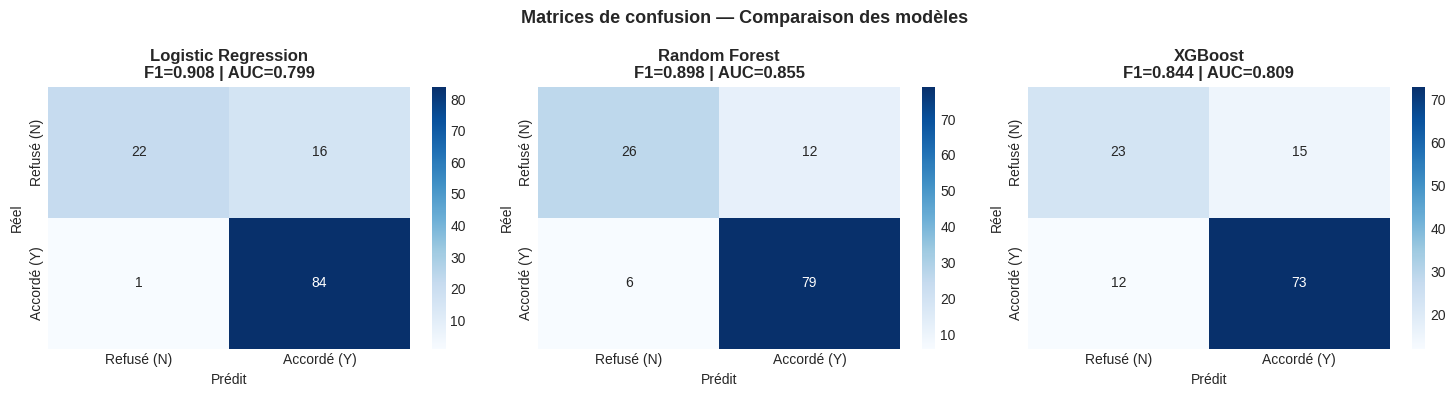

In [10]:
# === MATRICES DE CONFUSION ===

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Refusé (N)', 'Accordé (Y)'],
                yticklabels=['Refusé (N)', 'Accordé (Y)'])
    ax.set_title(f'{name}\nF1={r["f1"]:.3f} | AUC={r["roc_auc"]:.3f}', fontweight='bold')
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')

plt.suptitle('Matrices de confusion — Comparaison des modèles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

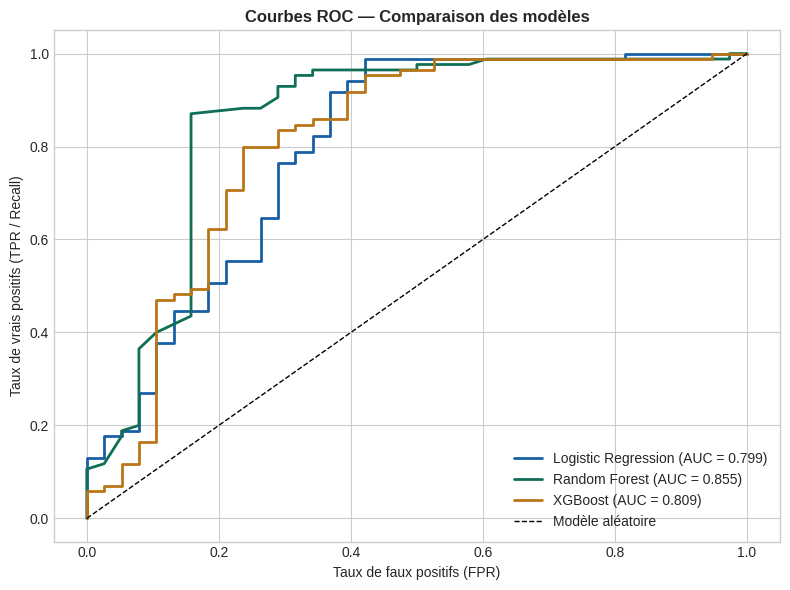

In [11]:
# === COURBES ROC ===

fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#185FA5', '#0F6E56', '#BA7517']
for (name, r), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{name} (AUC = {r['roc_auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Modèle aléatoire')
ax.set_xlabel('Taux de faux positifs (FPR)')
ax.set_ylabel('Taux de vrais positifs (TPR / Recall)')
ax.set_title('Courbes ROC — Comparaison des modèles', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

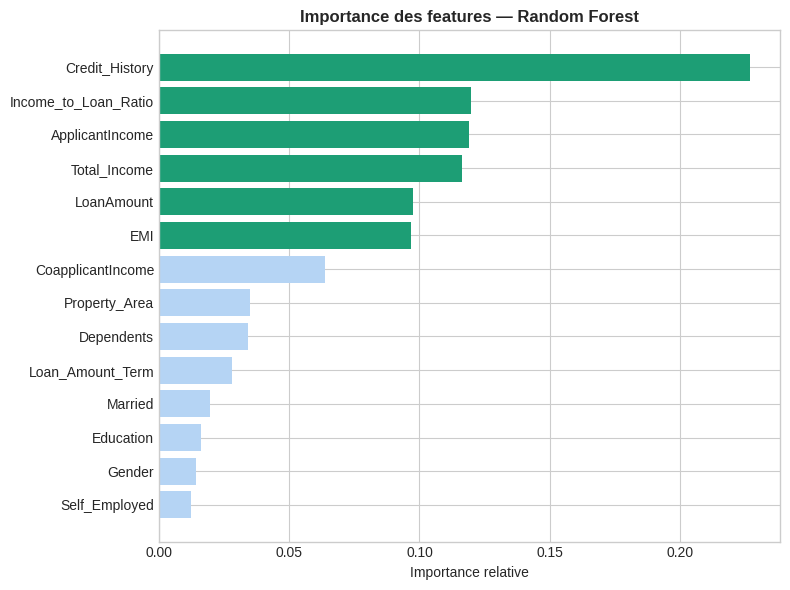


🏆 Top 5 features les plus importantes :
Credit_History          0.227030
Income_to_Loan_Ratio    0.119700
ApplicantIncome         0.118978
Total_Income            0.116504
LoanAmount              0.097656
dtype: float64


In [12]:
# === IMPORTANCE DES FEATURES (Random Forest) ===

rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(importances_sorted.index, importances_sorted.values,
               color=['#1D9E75' if v > 0.08 else '#B5D4F4' for v in importances_sorted.values])
ax.set_title('Importance des features — Random Forest', fontweight='bold')
ax.set_xlabel('Importance relative')
plt.tight_layout()
plt.show()

print('\n🏆 Top 5 features les plus importantes :')
print(importances.sort_values(ascending=False).head(5))

### Conclusion Exercice 3

**Modèle recommandé : Random Forest ou XGBoost**

- **Métrique principale** : F1-Score (équilibre entre Precision et Recall) car le dataset est déséquilibré
- **Métrique secondaire** : ROC-AUC pour évaluer la discrimination globale
- **Validation** : Cross-validation stratifiée k=5 pour évaluer la robustesse
- **Optimisation** : GridSearchCV pour l'hyperparamétrage, SMOTE si déséquilibre fort

> ⚠️ Le **Recall** est critique : un faux négatif (défaut non détecté) coûte bien plus cher à la banque qu'un faux positif (bon emprunteur refusé).

---
## 🌟 Exercice 4 — Solutions ML pour des problèmes spécifiques

### Scénario 1 : Prédiction de prix boursiers
**Type de ML → Supervised Learning (Régression)**

Les prix historiques et indicateurs financiers servent de **features** ; le prix futur est le **label** continu à prédire.  
Modèles adaptés : LSTM (séries temporelles), Random Forest Regressor, XGBoost Regressor.  
Métrique : RMSE, MAE, MAPE.

---

### Scénario 2 : Organisation d'une bibliothèque
**Type de ML → Unsupervised Learning (Clustering)**

Pas de genres pré-définis comme labels → on regroupe les livres par **similarité** de contenu.  
Modèles adaptés : K-Means, DBSCAN, Clustering hiérarchique.  
Évaluation : Silhouette Score, méthode du coude.

---

### Scénario 3 : Robot naviguant dans un labyrinthe
**Type de ML → Reinforcement Learning**

Le robot apprend par **essais/erreurs** : chaque action génère une récompense (+1 si avance, -1 si mur, +10 si sortie).  
L'algorithme (Q-Learning, Deep Q-Network) **maximise la récompense cumulée** pour trouver le chemin optimal.  
Il n'y a pas de dataset étiqueté — l'agent apprend seul en interagissant avec l'environnement.

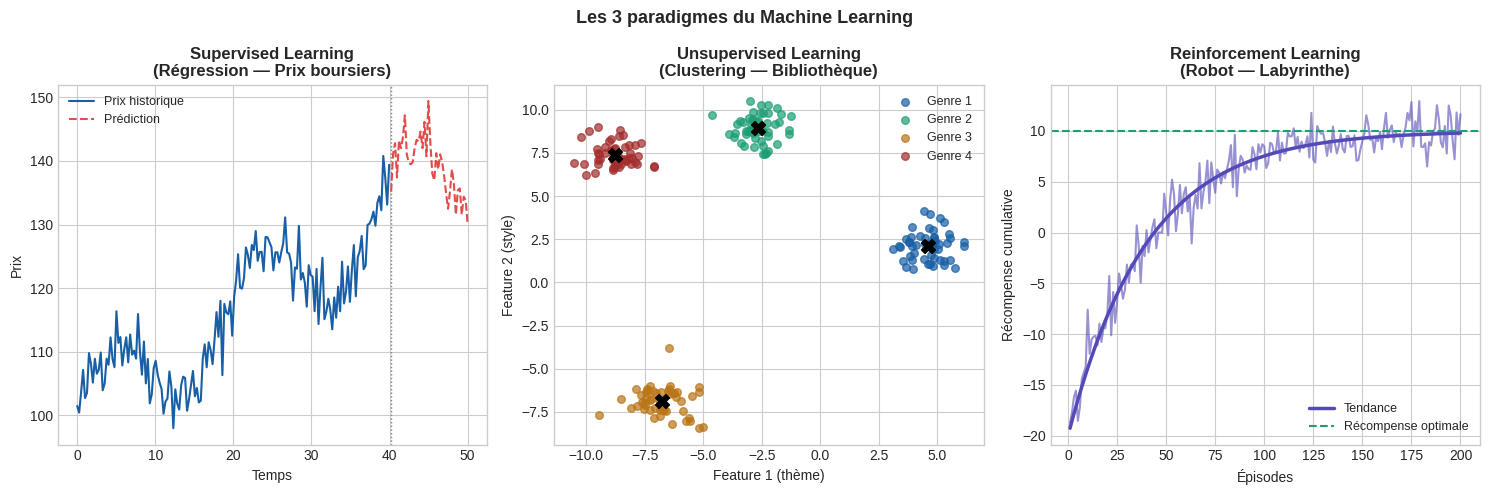

In [13]:
# Visualisation des 3 paradigmes ML
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Supervised : courbe de régression simulée ---
np.random.seed(42)
t = np.linspace(0, 50, 200)
price = 100 + 0.8*t + 8*np.sin(t/3) + np.random.normal(0, 3, 200)
axes[0].plot(t[:160], price[:160], color='#185FA5', lw=1.5, label='Prix historique')
axes[0].plot(t[160:], price[160:], color='#E24B4A', lw=1.5, linestyle='--', label='Prédiction')
axes[0].axvline(x=t[160], color='gray', linestyle=':', lw=1)
axes[0].set_title('Supervised Learning\n(Régression — Prix boursiers)', fontweight='bold')
axes[0].set_xlabel('Temps')
axes[0].set_ylabel('Prix')
axes[0].legend(fontsize=9)

# --- Unsupervised : clustering simulé ---
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
X_blob, _ = make_blobs(n_samples=200, centers=4, cluster_std=0.8, random_state=42)
km = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = km.fit_predict(X_blob)
colors_k = ['#185FA5', '#1D9E75', '#BA7517', '#A32D2D']
for k in range(4):
    axes[1].scatter(X_blob[labels==k, 0], X_blob[labels==k, 1],
                    c=colors_k[k], s=30, alpha=0.7, label=f'Genre {k+1}')
axes[1].scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
                c='black', s=100, marker='X', zorder=5)
axes[1].set_title('Unsupervised Learning\n(Clustering — Bibliothèque)', fontweight='bold')
axes[1].set_xlabel('Feature 1 (thème)')
axes[1].set_ylabel('Feature 2 (style)')
axes[1].legend(fontsize=9)

# --- Reinforcement : courbe de récompense cumulative ---
episodes = np.arange(1, 201)
rewards = -30 * np.exp(-episodes/40) + 10 + np.random.normal(0, 1.5, 200)
axes[2].plot(episodes, rewards, color='#534AB7', lw=1.5, alpha=0.6)
axes[2].plot(episodes, -30 * np.exp(-episodes/40) + 10, color='#534AB7', lw=2.5, label='Tendance')
axes[2].axhline(y=10, color='#1D9E75', linestyle='--', lw=1.5, label='Récompense optimale')
axes[2].set_title('Reinforcement Learning\n(Robot — Labyrinthe)', fontweight='bold')
axes[2].set_xlabel('Épisodes')
axes[2].set_ylabel('Récompense cumulative')
axes[2].legend(fontsize=9)

plt.suptitle('Les 3 paradigmes du Machine Learning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🌟 Exercice 5 — Stratégie d'évaluation pour 3 types de modèles ML

In [14]:
# === 1. SUPERVISED — Classification (Random Forest sur Loan Prediction) ===
print('=== ÉVALUATION SUPERVISED (Classification) ===')

rf = results['Random Forest']

# Rapport détaillé
print('\nRapport de classification :')
print(classification_report(y_test, rf['y_pred'], target_names=['Refusé (N)', 'Accordé (Y)']))

# Cross-validation
cv_f1 = cross_val_score(results['Random Forest']['model'], X, y, cv=5, scoring='f1')
cv_auc = cross_val_score(results['Random Forest']['model'], X, y, cv=5, scoring='roc_auc')
print(f'Cross-validation F1 (5-fold) : {cv_f1.mean():.3f} ± {cv_f1.std():.3f}')
print(f'Cross-validation AUC (5-fold): {cv_auc.mean():.3f} ± {cv_auc.std():.3f}')

# Défis
print('\n⚠️ Défis & limitations :')
print('- Déséquilibre des classes → surévaluation de l\'accuracy')
print('- Overfitting possible avec Random Forest profond')
print('- Interprétabilité réduite vs régression logistique')

=== ÉVALUATION SUPERVISED (Classification) ===

Rapport de classification :
              precision    recall  f1-score   support

  Refusé (N)       0.81      0.68      0.74        38
 Accordé (Y)       0.87      0.93      0.90        85

    accuracy                           0.85       123
   macro avg       0.84      0.81      0.82       123
weighted avg       0.85      0.85      0.85       123

Cross-validation F1 (5-fold) : 0.865 ± 0.012
Cross-validation AUC (5-fold): 0.776 ± 0.030

⚠️ Défis & limitations :
- Déséquilibre des classes → surévaluation de l'accuracy
- Overfitting possible avec Random Forest profond
- Interprétabilité réduite vs régression logistique


=== ÉVALUATION UNSUPERVISED (Clustering) ===


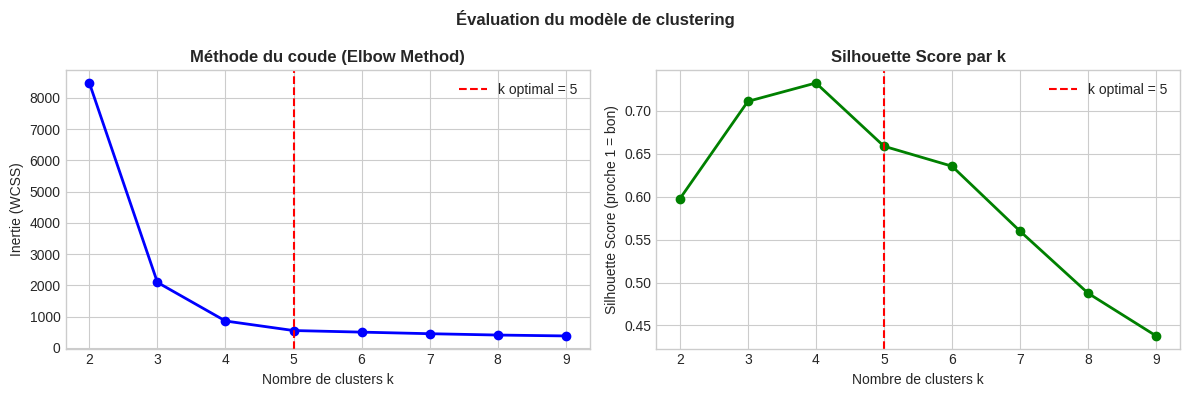


k=5 → Silhouette Score : 0.659 (proche 1 = clusters bien séparés)
k=5 → Davies-Bouldin Index : 0.493 (proche 0 = bon)

⚠️ Défis : Pas de vérité terrain → évaluation subjective. Sensible au choix de k.


In [15]:
# === 2. UNSUPERVISED — Clustering (K-Means simulé) ===
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

print('=== ÉVALUATION UNSUPERVISED (Clustering) ===')

X_lib, _ = make_blobs(n_samples=300, centers=5, cluster_std=1.0, random_state=42)

# Méthode du coude
inertias = []
silhouettes = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_lib)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_lib, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_range, inertias, 'bo-', lw=2)
axes[0].axvline(x=5, color='red', linestyle='--', label='k optimal = 5')
axes[0].set_title('Méthode du coude (Elbow Method)', fontweight='bold')
axes[0].set_xlabel('Nombre de clusters k')
axes[0].set_ylabel('Inertie (WCSS)')
axes[0].legend()

axes[1].plot(k_range, silhouettes, 'go-', lw=2)
axes[1].axvline(x=5, color='red', linestyle='--', label='k optimal = 5')
axes[1].set_title('Silhouette Score par k', fontweight='bold')
axes[1].set_xlabel('Nombre de clusters k')
axes[1].set_ylabel('Silhouette Score (proche 1 = bon)')
axes[1].legend()

plt.suptitle('Évaluation du modèle de clustering', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Score optimal
km_best = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_best = km_best.fit_predict(X_lib)
print(f'\nk=5 → Silhouette Score : {silhouette_score(X_lib, labels_best):.3f} (proche 1 = clusters bien séparés)')
print(f'k=5 → Davies-Bouldin Index : {davies_bouldin_score(X_lib, labels_best):.3f} (proche 0 = bon)')
print('\n⚠️ Défis : Pas de vérité terrain → évaluation subjective. Sensible au choix de k.')

=== ÉVALUATION REINFORCEMENT LEARNING ===


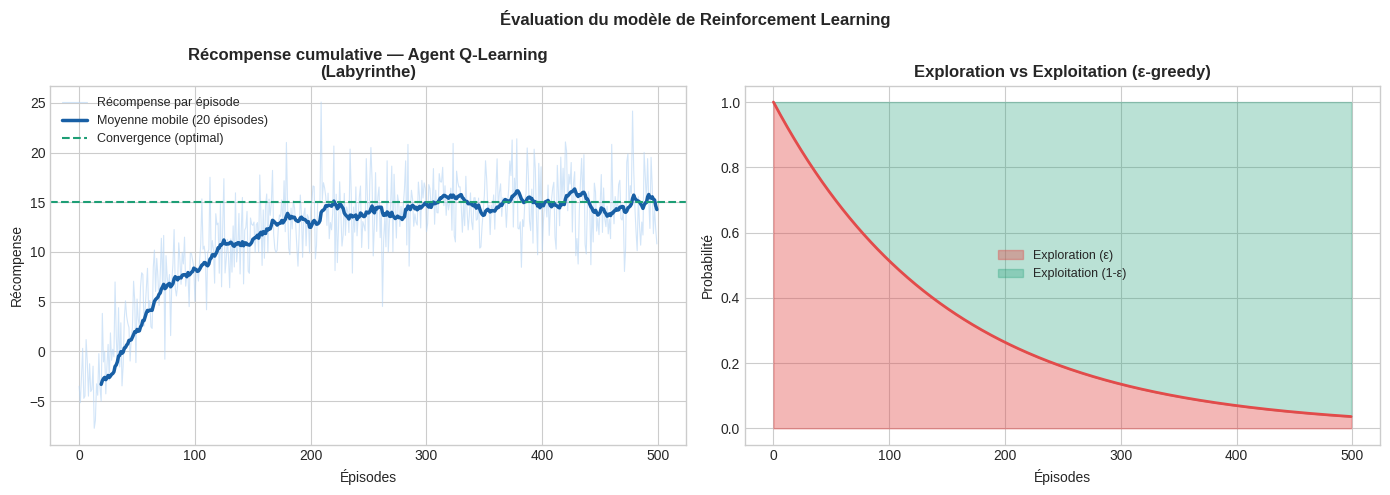

Récompense moyenne (100 derniers épisodes) : 14.75
Récompense moyenne (100 premiers épisodes) : 3.20

⚠️ Défis :
- Lent à converger (centaines/milliers d'épisodes)
- Sensible à la définition de la fonction de récompense
- Équilibre exploration/exploitation difficile à calibrer (ε-decay)
- Pas de ground truth → succès mesuré uniquement par la récompense


In [16]:
# === 3. REINFORCEMENT LEARNING — Simulation d'apprentissage ===
print('=== ÉVALUATION REINFORCEMENT LEARNING ===')

np.random.seed(42)
n_episodes = 500

# Simulation de la courbe d'apprentissage d'un agent Q-Learning dans un labyrinthe
# Formule : récompense cumulée augmente avec les épisodes, avec convergence
epsilon = np.exp(-np.arange(n_episodes) / 150)  # Exploration décroissante
base_reward = -20 * np.exp(-np.arange(n_episodes) / 80) + 15
noise = np.random.normal(0, 3, n_episodes)
cumulative_rewards = base_reward + noise

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Récompense cumulative
window = 20
smoothed = pd.Series(cumulative_rewards).rolling(window).mean()
axes[0].plot(cumulative_rewards, color='#B5D4F4', lw=0.8, alpha=0.6, label='Récompense par épisode')
axes[0].plot(smoothed, color='#185FA5', lw=2.5, label=f'Moyenne mobile ({window} épisodes)')
axes[0].axhline(y=15, color='#1D9E75', linestyle='--', lw=1.5, label='Convergence (optimal)')
axes[0].set_title('Récompense cumulative — Agent Q-Learning\n(Labyrinthe)', fontweight='bold')
axes[0].set_xlabel('Épisodes')
axes[0].set_ylabel('Récompense')
axes[0].legend(fontsize=9)

# Exploration vs Exploitation
axes[1].fill_between(range(n_episodes), epsilon, alpha=0.4, color='#E24B4A', label='Exploration (ε)')
axes[1].fill_between(range(n_episodes), epsilon, 1, alpha=0.3, color='#1D9E75', label='Exploitation (1-ε)')
axes[1].plot(epsilon, color='#E24B4A', lw=2)
axes[1].set_title('Exploration vs Exploitation (ε-greedy)', fontweight='bold')
axes[1].set_xlabel('Épisodes')
axes[1].set_ylabel('Probabilité')
axes[1].legend(fontsize=9)

plt.suptitle('Évaluation du modèle de Reinforcement Learning', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Récompense moyenne (100 derniers épisodes) : {np.mean(cumulative_rewards[-100:]):.2f}')
print(f'Récompense moyenne (100 premiers épisodes) : {np.mean(cumulative_rewards[:100]):.2f}')
print('\n⚠️ Défis :')
print('- Lent à converger (centaines/milliers d\'épisodes)')
print('- Sensible à la définition de la fonction de récompense')
print('- Équilibre exploration/exploitation difficile à calibrer (ε-decay)')
print('- Pas de ground truth → succès mesuré uniquement par la récompense')

---
## 📊 Récapitulatif final

| Exercice | Résultat clé |
|---|---|
| Ex 1 | Problème de classification binaire — données bancaires + bureaux de crédit |
| Ex 2 | `Credit_History`, revenus et montant du prêt = features les plus prédictives |
| Ex 3 | Random Forest recommandé — F1-Score et ROC-AUC comme métriques principales |
| Ex 4 | Bourse → Supervisé | Bibliothèque → Non-supervisé | Robot → Renforcement |
| Ex 5 | Chaque paradigme a sa propre logique d'évaluation sans métrique universelle |

---
*Notebook réalisé dans le cadre du cours Machine Learning — DI Bootcamp*